# Tugas Praktikum #1
## Pemrosesan Paralel

**Nama:** Afelia Nasyifa  
**NIM:** 2411513010  
**Kelas:** B

---

# 1. Klasifikasi Flynn
### a. Operasi `arr + arr` pada NumPy
Jawab: SIMD (Single Instruction, Multiple Data). Karena operasi `arr + arr` menggunakan satu operasi yang sama untuk memproses banyak elemen data pada array secara bersamaan. NumPy menggunakan operasi vectorized sehingga prosesnya lebih efisien dibandingkan melakukan perhitungan satu per satu menggunakan loop Python.

### b. Program Python biasa yang membaca file lalu memproses baris demi baris
Jawab: SISD (Single Instruction, Single Data). Karena program tersebut menjalankan instruksi secara berurutan dan memproses data satu per satu. Setiap baris file dibaca dan diproses sebelum melanjutkan ke baris berikutnya.

### c. Cluster komputer yang masing-masing node menjalankan simulasi cuaca berbeda secara independen
Jawaban: MIMD (Multiple Instruction, Multiple Data). Karena setiap node dapat menjalankan instruksi dan menggunakan data yang berbeda secara bersamaan. Contohnya, satu node menjalankan simulasi cuaca wilayah tertentu, sedangkan node lain menjalankan simulasi wilayah yang berbeda.

# 2. Analisis Hukum Amdahl
Diketahui aplikasi memiliki 85% bagian yang dapat diparalelkan, sehingga:

$$
P = 0.85
$$

Rumus Hukum Amdahl:

$$
S(N)=\frac{1}{(1-P)+\frac{P}{N}}
$$

Keterangan:
- $S(N)$ = speedup
- $N$ = jumlah prosesor
- $P$ = bagian program yang dapat diparalelkan
- $(1-P)$ = bagian program yang tidak dapat diparalelkan

N =  2 -> Speedup = 1.7391x
N =  4 -> Speedup = 2.7586x
N =  8 -> Speedup = 3.9024x
N = 16 -> Speedup = 4.9231x
N = 32 -> Speedup = 5.6637x
N = 64 -> Speedup = 6.1244x


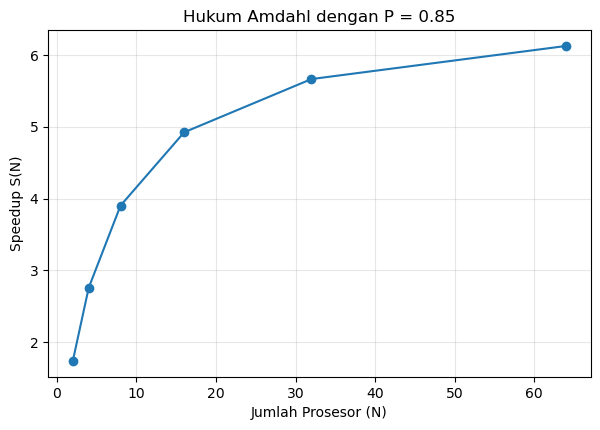

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

P = 0.85
N = np.array([2, 4, 8, 16, 32, 64])

speedup = amdahl_speedup(P, N)

for n, s in zip(N, speedup):
    print(f"N = {n:2d} -> Speedup = {s:.4f}x")

plt.figure(figsize=(7, 4.5))
plt.plot(N, speedup, marker='o')
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.title("Hukum Amdahl dengan P = 0.85")
plt.grid(alpha=0.3)
plt.show()

### a. Hasil Perhitungan Speedup

Berdasarkan perhitungan Hukum Amdahl, diperoleh:

| Jumlah Prosesor (N) | Speedup |
|---:|---:|
| 2 | 1.7391× |
| 4 | 2.7586× |
| 8 | 3.9024× |
| 16 | 4.9231× |
| 32 | 5.6637× |
| 64 | 6.1244× |

Dari hasil tersebut terlihat bahwa semakin banyak prosesor yang digunakan, speedup meningkat. Namun, peningkatannya semakin kecil ketika jumlah prosesor semakin besar.

### b. Plot Speedup vs N

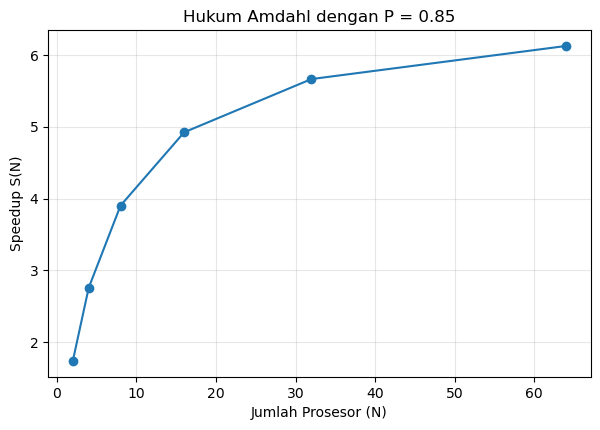

In [3]:
plt.figure(figsize=(7, 4.5))

plt.plot(N, speedup, marker='o')

plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.title("Hukum Amdahl dengan P = 0.85")
plt.grid(alpha=0.3)

plt.show()

### c. Diminishing Returns

Penambahan prosesor mulai memberikan manfaat yang semakin kecil pada sekitar N = 32 prosesor.

Pada N = 32, speedup yang diperoleh sekitar 5.66×. Ketika jumlah prosesor ditambah menjadi 64, speedup hanya meningkat menjadi sekitar 6.12×, atau bertambah sekitar 0.46×.

Hal ini terjadi karena terdapat 15% bagian program yang tidak dapat diparalelkan. Bagian tersebut tetap harus dijalankan secara serial sehingga menjadi batas speedup.

Speedup maksimum dapat dihitung dengan:

$$
S_{max} = \frac{1}{1-P}
$$

$$
S_{max} = \frac{1}{1-0.85} = 6.67
$$

Jadi, walaupun jumlah prosesor terus ditambah, speedup tidak akan melebihi sekitar 6.67×.

# 3. Benchmark Mandiri
Pada bagian ini dilakukan benchmark terhadap fungsi CPU-bound. Pengukuran dilakukan menggunakan `time.perf_counter()` dan `timeit` pada beberapa ukuran input. Fungsi yang digunakan adalah fungsi `hitung_prima()` untuk mencari bilangan prima sampai batas tertentu.

In [9]:
import time
import timeit
import matplotlib.pyplot as plt

def hitung_prima(n):
    primes = []

    for num in range(2, n):
        is_prime = True

        for i in range(2, int(num * 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break

        if is_prime:
            primes.append(num)

    return primes

### Pengukuran dengan `time.perf_counter()` dan `timeit`

Saya menggunakan empat ukuran input, yaitu 10.000, 20.000, 40.000, dan 80.000.

In [7]:
ukuran_input = [10000, 20000, 40000, 80000]

hasil_perf = []
hasil_timeit = []

for n in ukuran_input:
    # perf_counter
    start = time.perf_counter()
    hitung_prima(n)
    waktu_perf = time.perf_counter() - start
    hasil_perf.append(waktu_perf)

    # timeit
    waktu_timeit = min(
        timeit.repeat(
            lambda: hitung_prima(n),
            repeat=5,
            number=1
        )
    )
    hasil_timeit.append(waktu_timeit)

    print(f"N = {n:6d} -> perf_counter = {waktu_perf:.4f} detik, "
          f"timeit = {waktu_timeit:.4f} detik")

N =  10000 -> perf_counter = 0.2094 detik, timeit = 0.1933 detik
N =  20000 -> perf_counter = 0.7371 detik, timeit = 0.7386 detik
N =  40000 -> perf_counter = 2.8521 detik, timeit = 2.8775 detik
N =  80000 -> perf_counter = 11.0830 detik, timeit = 11.1341 detik


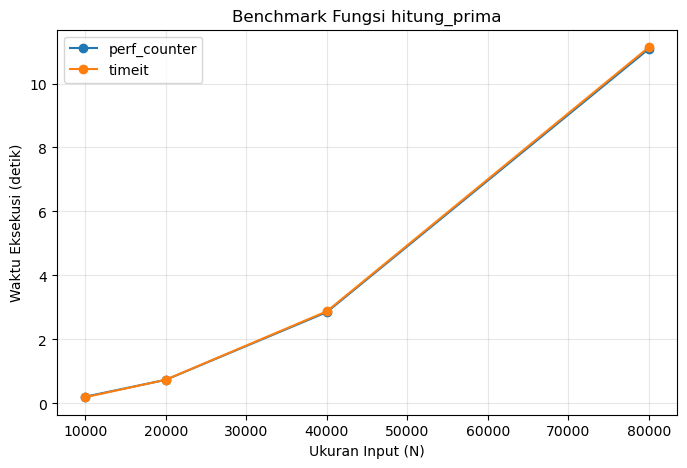

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    ukuran_input,
    hasil_perf,
    marker='o',
    label='perf_counter'
)

plt.plot(
    ukuran_input,
    hasil_timeit,
    marker='o',
    label='timeit'
)

plt.xlabel("Ukuran Input (N)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.title("Benchmark Fungsi hitung_prima")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Analisis Benchmark

Dari hasil benchmark, dapat dilihat bahwa waktu eksekusi bertambah ketika ukuran input semakin besar. Hal ini menunjukkan bahwa semakin banyak data yang diproses, semakin lama waktu yang dibutuhkan oleh fungsi `hitung_prima()`. Hasil `perf_counter()` dan `timeit` tidak selalu sama karena `perf_counter()` melakukan pengukuran secara langsung, sedangkan `timeit` menjalankan pengukuran beberapa kali. `timeit` lebih cocok digunakan untuk benchmarking karena hasilnya lebih stabil terhadap gangguan sementara dari sistem. Dari grafik juga terlihat bahwa pertambahan ukuran input menyebabkan waktu eksekusi meningkat cukup besar. Hal ini sesuai dengan karakteristik fungsi `hitung_prima()` yang melakukan banyak operasi pengecekan bilangan.

# 4. Refleksi Singkat
### Kapan Hukum Amdahl lebih relevan digunakan dibanding Hukum Gustafson, dan sebaliknya?

Menurut saya, Hukum Amdahl lebih cocok digunakan ketika ukuran masalah yang dikerjakan tetap. Contohnya pada sebuah program pengolahan data yang memiliki 85% proses yang bisa dijalankan secara paralel, sedangkan 15% sisanya harus dijalankan secara serial. Walaupun jumlah prosesor ditambah, bagian serial tersebut tetap menjadi batas peningkatan performa. Jadi, Hukum Amdahl dapat digunakan untuk mengetahui batas speedup dari program tersebut. Sedangkan Hukum Gustafson lebih cocok ketika jumlah prosesor bertambah dan ukuran masalah juga ikut diperbesar. Contohnya pada simulasi cuaca. Jika awalnya menggunakan 4 prosesor untuk melakukan simulasi dalam suatu wilayah, kemudian jumlah prosesor ditambah menjadi 16, maka komputer dapat digunakan untuk melakukan simulasi dengan data yang lebih besar atau wilayah yang lebih luas dalam waktu yang relatif sama. Jadi, Hukum Amdahl lebih sesuai untuk ukuran masalah yang tetap, sedangkan Hukum Gustafson lebih sesuai untuk ukuran masalah yang dapat diperbesar mengikuti jumlah prosesor.